In [42]:
import urllib.request
import os
path = os.path.expanduser("~/Desktop/Drug-Discovery-ML")
print(path)

url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/delaney-processed.csv"
urllib.request.urlretrieve(url, "esol.csv")
print("downloaded")

/Users/shivani/Desktop/Drug-Discovery-ML
downloaded


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("imported")



imported


In [44]:
df = pd.read_csv("esol.csv")
df.head()
df.shape
print(df.columns.to_list())


['Compound ID', 'ESOL predicted log solubility in mols per litre', 'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors', 'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area', 'measured log solubility in mols per litre', 'smiles']


In [45]:
df.describe()
df_1 = df.rename(columns={"measured log solubility in mols per litre": "logS", "Molecular Weight": "mol_weight", "Number of H-Bond Donors": "num_H_bond_donors", "Number of Rings":"n_rings","Polar Surface Area":"PSA" })

print(df_1.columns.to_list())
df_1.head()
print(df_1.dtypes)
print(df_1['logS'].isnull().sum())
print(df[df_1['logS'].isnull()])

['Compound ID', 'ESOL predicted log solubility in mols per litre', 'Minimum Degree', 'mol_weight', 'num_H_bond_donors', 'n_rings', 'Number of Rotatable Bonds', 'PSA', 'logS', 'smiles']
Compound ID                                         object
ESOL predicted log solubility in mols per litre    float64
Minimum Degree                                       int64
mol_weight                                         float64
num_H_bond_donors                                    int64
n_rings                                              int64
Number of Rotatable Bonds                            int64
PSA                                                float64
logS                                               float64
smiles                                              object
dtype: object
0
Empty DataFrame
Columns: [Compound ID, ESOL predicted log solubility in mols per litre, Minimum Degree, Molecular Weight, Number of H-Bond Donors, Number of Rings, Number of Rotatable Bonds, Polar Surface Area

In [46]:
# Key stats
print("=== Solubility (logS) ===")
print(df_1['logS'].describe().round(2))

# Solubility categories
print(f"\nHighly soluble (logS > 0):   {(df_1['logS'] > 0).sum()} molecules")
print(f"Poorly soluble (logS < -5):  {(df_1['logS'] < -5).sum()} molecules")
print(f"Drug-like (MW < 500):        {(df_1['mol_weight'] < 500).sum()} molecules")

=== Solubility (logS) ===
count    1128.00
mean       -3.05
std         2.10
min       -11.60
25%        -4.32
50%        -2.86
75%        -1.60
max         1.58
Name: logS, dtype: float64

Highly soluble (logS > 0):   66 molecules
Poorly soluble (logS < -5):  180 molecules
Drug-like (MW < 500):        1119 molecules


In [48]:
print((df_1['logS']>0).sum())
print((df_1['logS']<-5).sum())
print((df_1['mol_weight']< 500).sum())

66
180
1119


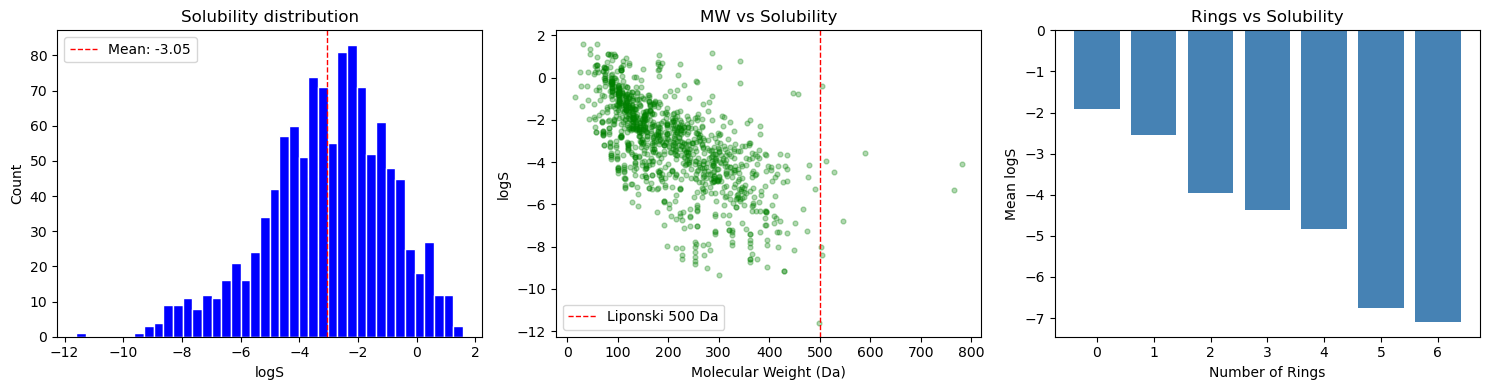

In [55]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,3, figsize= (15,4))

# Plot 1:Solubility distribution
axes[0].hist(df_1['logS'], bins =40, color= 'blue', edgecolor='white')
axes[0].axvline(df_1['logS'].mean(), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {df_1["logS"].mean():.2f}')
axes[0].set_xlabel('logS'); axes[0].set_ylabel('Count')
axes[0].set_title('Solubility distribution')
axes[0].legend()

# Plot 2: Molecular weight vs solubility
axes[1].scatter(df_1['mol_weight'], df_1['logS'], alpha=0.3, s=12, color='green')
axes[1].axvline(500, color='red', linestyle='dashed', linewidth=1,label='Liponski 500 Da')
axes[1].set_xlabel('Molecular Weight (Da)')
axes[1].set_ylabel('logS')
axes[1].set_title('MW vs Solubility')
axes[1].legend()

# Plot 3: Mean soloubility by number of H-bond donors

ring_names = df_1.groupby('n_rings')['logS'].mean().head(7)
axes[2].bar(ring_names.index, ring_names.values, color='steelblue')
axes[2].set_xlabel('Number of Rings')
axes[2].set_ylabel('Mean logS')
axes[2].set_title('Rings vs Solubility')

plt.tight_layout()
plt.savefig('esol_analysis.png', dpi=150)
plt.show()

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
feature_cols = ['mol_weight', 'n_rings', 'num_H_bond_donors', 'PSA']
X = df_1[feature_cols].to_numpy()
y = df_1['logS'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse =np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Linear Regression RMSE: {rmse:.3f} logS units")
print(f"(In month 2 your MLP will beat this)")

Linear Regression RMSE: 1.242 logS units
(In month 2 your MLP will beat this)
